In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()

In [2]:
m = 1.0
E_min = 2.05
E_max = 4.2
E_grid = np.linspace(E_min, E_max, 550)
pole_buffer = 2e-3
sigma_E = 0.010

Ls = np.array([4.0, 5.0, 6.0])
frames = {
    "000": np.array([0, 0, 0], dtype=int),
    "001": np.array([0, 0, 1], dtype=int),
    "011": np.array([0, 1, 1], dtype=int),
    "111": np.array([1, 1, 1], dtype=int),
    "002": np.array([0, 0, 2], dtype=int),
}
frame_names = list(frames.keys())
print(f"Frames: {frame_names}")
frame_offsets = dict(zip(frame_names, np.linspace(-0.26, 0.26, len(frame_names))))


def Kinv_true(E):
    E = np.asarray(E, dtype=float)
    return -1 + 1/2*((E/2)**2 - m**2)


_noninteracting_cache = {}


def noninteracting_levels(L, dvec, nmax=5):
    """Two-particle noninteracting E* poles for total momentum 2*pi*dvec/L."""
    dvec = np.asarray(dvec, dtype=int)
    key = (float(L), tuple(int(x) for x in dvec), int(nmax))
    if key in _noninteracting_cache:
        return _noninteracting_cache[key]

    P = 2*np.pi*dvec/L
    poles = []

    ns = range(-nmax, nmax + 1)
    for nx in ns:
        for ny in ns:
            for nz in ns:
                n = np.array([nx, ny, nz], dtype=int)
                p1 = 2*np.pi*n/L
                p2 = 2*np.pi*(dvec - n)/L
                E_lab = np.sqrt(m**2 + np.dot(p1, p1)) + np.sqrt(m**2 + np.dot(p2, p2))
                E_cm_sq = E_lab**2 - np.dot(P, P)
                if E_cm_sq <= 0:
                    continue
                E_cm = np.sqrt(E_cm_sq)
                if E_min - 0.05 < E_cm < E_max + 0.05:
                    poles.append(E_cm)

    poles = np.array(sorted(poles), dtype=float)
    if len(poles) == 0:
        _noninteracting_cache[key] = poles
        return poles

    # Collapse degeneracies so the finite-volume function has one pole per shell.
    unique = [poles[0]]
    for p in poles[1:]:
        if abs(p - unique[-1]) > 1e-5:
            unique.append(p)
    unique = np.array(unique, dtype=float)
    _noninteracting_cache[key] = unique
    return unique


def F_fv(E, L, frame):
    """Toy finite-volume function with the right dependence on L and moving frame."""
    E = np.asarray(E, dtype=float)
    poles = noninteracting_levels(L, frames[frame])
    out = np.zeros_like(E, dtype=float)

    for k, pole in enumerate(poles):
        weight = 0.035/(1 + k)
        out += weight/(E - pole)

    d2 = np.dot(frames[frame], frames[frame])
    return out + 0.04*(E - 2.7) + 0.01*d2*(E - 3.0)


def roots_from_grid(QC, L, frame, min_sep=0.018):
    QC = np.asarray(QC, dtype=float)
    poles = noninteracting_levels(L, frames[frame])

    good = np.isfinite(QC) & (np.abs(QC) < 300.0)
    for pole in poles:
        good &= np.abs(E_grid - pole) > pole_buffer

    # Vectorized zero-crossing search. This is called thousands of times inside the MCMC,
    # so avoiding a Python loop over the full energy grid matters.
    mask = good[:-1] & good[1:] & (QC[:-1]*QC[1:] < 0.0)
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return np.array([], dtype=float)

    E_left = E_grid[idx]
    E_right = E_grid[idx + 1]
    Q_left = QC[idx]
    Q_right = QC[idx + 1]
    candidates = E_left - Q_left*(E_right - E_left)/(Q_right - Q_left)
    candidates = candidates[(E_min < candidates) & (candidates < E_max)]

    roots = []
    for E0 in candidates:
        if np.any(np.abs(E0 - poles) < 1.5*pole_buffer):
            continue
        if all(abs(E0 - old) > min_sep for old in roots):
            roots.append(float(E0))

    return np.array(roots, dtype=float)


def spectrum_from_Kinv(Kinv_function, L, frame):
    return roots_from_grid(Kinv_function(E_grid) + F_fv(E_grid, L, frame), L, frame)


Frames: ['000', '001', '011', '111', '002']


In [3]:
rows = []
true_rows = []

for L in Ls:
    for frame in frame_names:
        E_true_levels = spectrum_from_Kinv(Kinv_true, L, frame)
        for level_index, E_true in enumerate(E_true_levels):
            E_obs = E_true + rng.normal(0.0, sigma_E)
            row = {
                "L": float(L),
                "frame": frame,
                "level_index": level_index,
                "E_true": float(E_true),
                "E_obs": float(E_obs),
                "dE": sigma_E,
            }
            rows.append(row)
            true_rows.append(row.copy())

data = rows
print(f"generated {len(data)} finite-volume levels across {len(Ls)} volumes and {len(frame_names)} frames")


generated 46 finite-volume levels across 3 volumes and 5 frames


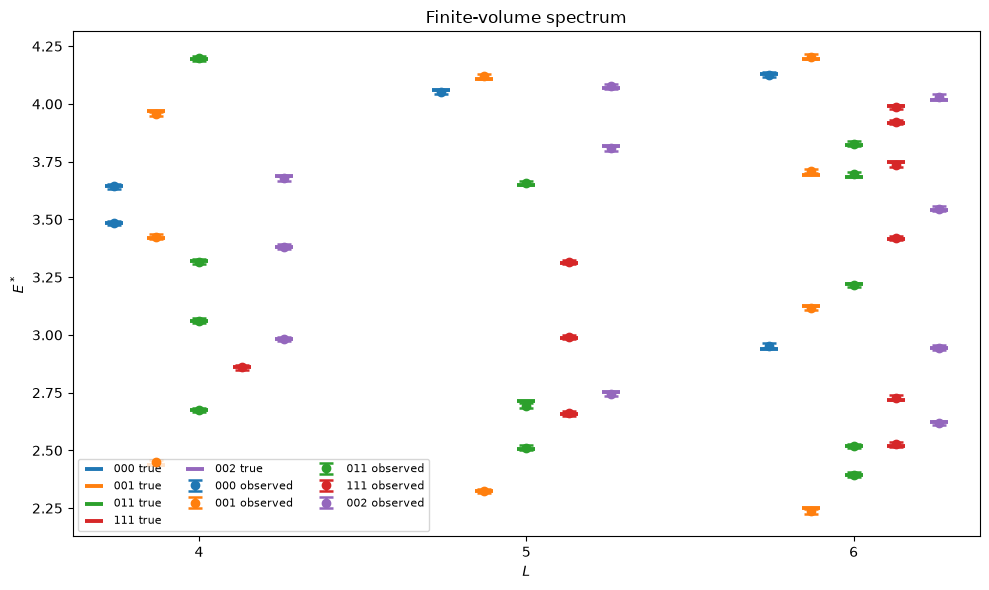

In [4]:
def plot_spectrum(level_rows, title="Finite-volume spectrum", include_observed=True, include_true=True, predicted_rows=None):
    plt.figure(figsize=(10, 6))

    for frame in frame_names:
        offset = frame_offsets[frame]
        rows_frame = [r for r in level_rows if r["frame"] == frame]

        if include_observed:
            x_obs = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_obs = np.array([r["E_obs"] for r in rows_frame], dtype=float)
            yerr = np.array([r["dE"] for r in rows_frame], dtype=float)

            plt.errorbar(
                x_obs,
                y_obs,
                yerr=yerr,
                fmt="o",
                markersize=6,
                capsize=5,
                capthick=1.8,
                elinewidth=1.8,
                linewidth=0,
                label=f"{frame} observed",
                zorder=5,
            )

        if include_true:
            x_true = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_true = np.array([r["E_true"] for r in rows_frame], dtype=float)

            plt.scatter(
                x_true,
                y_true,
                marker="_",
                s=180,
                linewidths=2.8,
                label=f"{frame} true",
                zorder=4,
            )

    if predicted_rows is not None:
        for frame in frame_names:
            offset = frame_offsets[frame]
            rows_frame = [r for r in predicted_rows if r["frame"] == frame]
            x_pred = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_pred = np.array([r["E_pred"] for r in rows_frame], dtype=float)

            plt.scatter(
                x_pred,
                y_pred,
                marker="x",
                s=70,
                linewidths=2.2,
                label=f"{frame} GP",
                zorder=6,
            )

    plt.xticks(Ls, [str(int(L)) for L in Ls])
    plt.xlabel(r"$L$")
    plt.ylabel(r"$E^*$")
    plt.title(title)
    plt.legend(ncols=3, fontsize=8)
    plt.tight_layout()
    plt.show()


plot_spectrum(data, "Finite-volume spectrum")

In [5]:
n_knots = 7
knots = np.linspace(E_min, E_max, n_knots)

F_grids = {
    (float(L), frame): F_fv(E_grid, L, frame)
    for L in Ls
    for frame in frame_names
}

obs_by_key = {
    (float(L), frame): [r for r in data if r["L"] == float(L) and r["frame"] == frame]
    for L in Ls
    for frame in frame_names
}

# Do not set these exactly to zero.
# sigma=0 collapses the GP covariance.
# l_c=0 causes division by zero in the RBF kernel.
sigma_min, sigma_max = 1e-3, 5.0
lc_min, lc_max = 1e-3, 5.0


def kernel(x, y, sigma, l_c):
    if sigma <= 0 or l_c <= 0:
        raise np.linalg.LinAlgError("sigma and l_c must be positive")

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    return sigma**2*np.exp(-0.5*((x[:, None] - y[None, :])/l_c)**2)


def gp_matrices(sigma, l_c):
    C = kernel(knots, knots, sigma, l_c) + 1e-8*np.eye(n_knots)

    sign, logdet = np.linalg.slogdet(C)
    if sign <= 0:
        raise np.linalg.LinAlgError("GP covariance is not positive definite")

    C_inv = np.linalg.inv(C)
    interp_grid = kernel(E_grid, knots, sigma, l_c) @ C_inv

    return C, C_inv, logdet, interp_grid


def predict_levels_from_gp(f_knots, interp_grid, L, frame):
    K_grid = interp_grid @ f_knots
    return roots_from_grid(K_grid + F_grids[(float(L), frame)], L, frame)


def log_likelihood(f_knots, interp_grid, level_penalty=30.0, max_pull=10.0):
    """Gaussian level likelihood, with a soft penalty when the predicted spectrum has the wrong count."""
    loglike = 0.0

    for L in Ls:
        for frame in frame_names:
            obs = obs_by_key[(float(L), frame)]
            E_obs = np.array([r["E_obs"] for r in obs], dtype=float)
            dE = np.array([r["dE"] for r in obs], dtype=float)

            E_pred = predict_levels_from_gp(f_knots, interp_grid, L, frame)
            used = np.zeros(len(E_pred), dtype=bool)

            for E, sig in zip(E_obs, dE):
                if len(E_pred) == 0:
                    loglike += -0.5*level_penalty
                    continue

                distances = np.abs(E_pred - E)
                distances[used] = np.inf
                j = np.argmin(distances)
                pull = distances[j]/sig

                if np.isfinite(pull) and pull < max_pull:
                    loglike += -0.5*pull**2 - np.log(sig*np.sqrt(2*np.pi))
                    used[j] = True
                else:
                    loglike += -0.5*level_penalty

            loglike += -0.5*level_penalty*abs(len(E_pred) - len(E_obs))

    return float(loglike)


def log_hyperprior(sigma, l_c):
    if not (sigma_min <= sigma <= sigma_max and lc_min <= l_c <= lc_max):
        return -np.inf

    # Strictly exclude zero, even if the bounds are accidentally changed.
    if sigma <= 0 or l_c <= 0:
        return -np.inf

    return -np.log(sigma_max - sigma_min) - np.log(lc_max - lc_min)


def log_posterior(f_knots, sigma, l_c):
    # Bayes theorem: log posterior = log likelihood + log GP prior + log hyperprior + constant.
    hp = log_hyperprior(sigma, l_c)
    if not np.isfinite(hp):
        return -np.inf, -np.inf, -np.inf

    try:
        _, C_inv, logdet, interp_grid = gp_matrices(sigma, l_c)
    except np.linalg.LinAlgError:
        return -np.inf, -np.inf, -np.inf
    except FloatingPointError:
        return -np.inf, -np.inf, -np.inf
    except ValueError:
        return -np.inf, -np.inf, -np.inf

    f_knots = np.asarray(f_knots, dtype=float)

    gp_prior = (
        -0.5*f_knots @ C_inv @ f_knots
        -0.5*logdet
        -0.5*n_knots*np.log(2*np.pi)
    )

    logprior = float(gp_prior + hp)
    ll = log_likelihood(f_knots, interp_grid)

    return float(ll + logprior), float(ll), float(logprior)


def Kinv_gp_values(f_knots, sigma, l_c, E):
    E = np.asarray(E, dtype=float)
    _, C_inv, _, _ = gp_matrices(sigma, l_c)
    return kernel(E, knots, sigma, l_c) @ C_inv @ f_knots

In [6]:
# Parallel-tempered MCMC for p(K^{-1} knots, l_c, sigma | finite-volume levels).
# The beta=1 chain is the real posterior.
# Hot chains have beta<1 and explore more freely.

n_steps = 100000 #10000
burn_in = 500
thin = 5
print_every = 500

# Temperature ladder.
# beta=0 samples GP prior + hyperprior, not literally a flat box in hyperparameters.
betas = np.array([0.0, 0.02, 0.05, 0.10, 0.20, 0.40, 0.70, 1.00])
n_chains = len(betas)

# Function proposal widths.
proposal_width_f_one = 0.10
proposal_width_f_all = 0.06
proposal_width_const = 0.20

# Positive hyperparameter proposals.
# These are random walks in log(sigma), log(l_c).
proposal_width_log_lc = 0.20
proposal_width_log_sigma = 0.20

# Occasional independent GP-prior function refresh.
p_prior_function_refresh = 0.04

# Try swaps every this many steps.
swap_every = 10


def reflect_log_into_box(logx, log_lo, log_hi):
    width = log_hi - log_lo
    if width <= 0:
        raise ValueError("bad log box")

    while logx < log_lo or logx > log_hi:
        if logx < log_lo:
            logx = log_lo + (log_lo - logx)
        if logx > log_hi:
            logx = log_hi - (logx - log_hi)

    return logx


def log_tempered_target(f_knots, sigma, l_c, beta):
    logpost, loglike, logprior = log_posterior(f_knots, sigma, l_c)

    if not np.isfinite(logpost):
        return -np.inf, loglike, logprior

    return beta*loglike + logprior, loglike, logprior


def draw_tame_function():
    """
    Non-cheating function proposal.
    This is not K^{-1} = -F.
    It just prevents the chain from starting with a wildly pathological spectrum.
    """
    constant = rng.normal(scale=1.0)
    return constant + 0.25*rng.normal(size=n_knots)


def draw_tame_state():
    sigma = rng.uniform(sigma_min, sigma_max)
    l_c = rng.uniform(lc_min, lc_max)
    f_knots = draw_tame_function()

    return f_knots, sigma, l_c


def draw_function_from_gp_prior(sigma, l_c):
    C, _, _, _ = gp_matrices(sigma, l_c)
    return rng.multivariate_normal(np.zeros(n_knots), C)


# Initialize all chains.
chains_f = []
chains_sigma = []
chains_lc = []
chains_logtarget = []
chains_loglike = []
chains_logprior = []

for c in range(n_chains):
    best = None

    # For each temperature, try a few starts and keep the best tempered target.
    for attempt in range(20):
        f0, sigma0, lc0 = draw_tame_state()
        lt0, ll0, lp0 = log_tempered_target(f0, sigma0, lc0, betas[c])

        if best is None or lt0 > best[0]:
            best = (lt0, ll0, lp0, f0.copy(), sigma0, lc0)

    lt0, ll0, lp0, f0, sigma0, lc0 = best

    chains_f.append(f0.copy())
    chains_sigma.append(sigma0)
    chains_lc.append(lc0)
    chains_logtarget.append(lt0)
    chains_loglike.append(ll0)
    chains_logprior.append(lp0)

chains_f = np.array(chains_f)
chains_sigma = np.array(chains_sigma)
chains_lc = np.array(chains_lc)
chains_logtarget = np.array(chains_logtarget)
chains_loglike = np.array(chains_loglike)
chains_logprior = np.array(chains_logprior)

samples_f = []
samples_sigma = []
samples_lc = []
logpost_samples = []
loglike_samples = []
logprior_samples = []

accepted = np.zeros(n_chains, dtype=int)
proposed = np.zeros(n_chains, dtype=int)

swap_accepted = np.zeros(n_chains - 1, dtype=int)
swap_proposed = np.zeros(n_chains - 1, dtype=int)

best_f = None
best_sigma = None
best_lc = None
best_logpost = -np.inf
best_loglike = -np.inf
best_logprior = -np.inf


for step in range(n_steps):

    # Within-chain Metropolis updates.
    for c in range(n_chains):
        beta = betas[c]

        f_current = chains_f[c].copy()
        sigma_current = chains_sigma[c]
        lc_current = chains_lc[c]
        logtarget_current = chains_logtarget[c]

        f_trial = f_current.copy()
        sigma_trial = sigma_current
        lc_trial = lc_current
        log_q_correction = 0.0

        move = rng.random()

        if move < p_prior_function_refresh:
            # Refresh the function from the GP prior at the current hyperparameters.
            # No hyperparameters move here.
            f_trial = draw_function_from_gp_prior(sigma_trial, lc_trial)

        elif move < 0.40:
            # One-knot local move.
            k = rng.integers(n_knots)
            f_trial[k] += proposal_width_f_one*rng.normal()

        elif move < 0.65:
            # All-knot random walk.
            f_trial += proposal_width_f_all*rng.normal(size=n_knots)

        elif move < 0.80:
            # Vertical shift.
            f_trial += proposal_width_const*rng.normal()

        elif move < 0.90:
            # Multiplicative l_c move.
            log_lc_min = np.log(lc_min)
            log_lc_max = np.log(lc_max)

            log_lc_current = np.log(lc_current)
            log_lc_trial = reflect_log_into_box(
                log_lc_current + proposal_width_log_lc*rng.normal(),
                log_lc_min,
                log_lc_max,
            )

            lc_trial = np.exp(log_lc_trial)

            # Hastings correction for proposing symmetrically in log(l_c)
            # while targeting a density uniform in l_c.
            log_q_correction = np.log(lc_trial) - np.log(lc_current)

        else:
            # Multiplicative sigma move.
            log_sigma_min = np.log(sigma_min)
            log_sigma_max = np.log(sigma_max)

            log_sigma_current = np.log(sigma_current)
            log_sigma_trial = reflect_log_into_box(
                log_sigma_current + proposal_width_log_sigma*rng.normal(),
                log_sigma_min,
                log_sigma_max,
            )

            sigma_trial = np.exp(log_sigma_trial)

            # Hastings correction for proposing symmetrically in log(sigma)
            # while targeting a density uniform in sigma.
            log_q_correction = np.log(sigma_trial) - np.log(sigma_current)

        logtarget_trial, loglike_trial, logprior_trial = log_tempered_target(
            f_trial,
            sigma_trial,
            lc_trial,
            beta,
        )

        proposed[c] += 1

        if np.log(rng.random()) < logtarget_trial - logtarget_current + log_q_correction:
            chains_f[c] = f_trial.copy()
            chains_sigma[c] = sigma_trial
            chains_lc[c] = lc_trial
            chains_logtarget[c] = logtarget_trial
            chains_loglike[c] = loglike_trial
            chains_logprior[c] = logprior_trial
            accepted[c] += 1

    # Parallel-tempering swaps.
    if (step + 1) % swap_every == 0:
        for c in range(n_chains - 1):
            beta_a = betas[c]
            beta_b = betas[c + 1]

            ll_a = chains_loglike[c]
            ll_b = chains_loglike[c + 1]

            # Priors cancel in the swap ratio because both chains use the same prior.
            log_swap_ratio = (beta_a - beta_b)*(ll_b - ll_a)

            swap_proposed[c] += 1

            if np.log(rng.random()) < log_swap_ratio:
                chains_f[[c, c + 1]] = chains_f[[c + 1, c]]
                chains_sigma[[c, c + 1]] = chains_sigma[[c + 1, c]]
                chains_lc[[c, c + 1]] = chains_lc[[c + 1, c]]
                chains_loglike[[c, c + 1]] = chains_loglike[[c + 1, c]]
                chains_logprior[[c, c + 1]] = chains_logprior[[c + 1, c]]

                chains_logtarget[c] = betas[c]*chains_loglike[c] + chains_logprior[c]
                chains_logtarget[c + 1] = betas[c + 1]*chains_loglike[c + 1] + chains_logprior[c + 1]

                swap_accepted[c] += 1

    # The beta=1 chain is the final chain.
    cold = n_chains - 1

    cold_logpost, cold_loglike, cold_logprior = log_posterior(
        chains_f[cold],
        chains_sigma[cold],
        chains_lc[cold],
    )

    if cold_logpost > best_logpost:
        best_f = chains_f[cold].copy()
        best_sigma = chains_sigma[cold]
        best_lc = chains_lc[cold]
        best_logpost = cold_logpost
        best_loglike = cold_loglike
        best_logprior = cold_logprior

    if step >= burn_in and step % thin == 0:
        samples_f.append(chains_f[cold].copy())
        samples_sigma.append(chains_sigma[cold])
        samples_lc.append(chains_lc[cold])
        logpost_samples.append(cold_logpost)
        loglike_samples.append(cold_loglike)
        logprior_samples.append(cold_logprior)

    if print_every and (step + 1) % print_every == 0:
        acc_rates = accepted/np.maximum(proposed, 1)
        swap_rates = swap_accepted/np.maximum(swap_proposed, 1)

        print(f"step {step + 1}/{n_steps}")
        print(
            "  chain acceptance:",
            " ".join([f"b={betas[i]:.2g}:{acc_rates[i]:.2f}" for i in range(n_chains)])
        )
        print(
            "  swap acceptance:",
            " ".join([f"{i}-{i+1}:{swap_rates[i]:.2f}" for i in range(n_chains - 1)])
        )
        print(
            f"  cold current: log posterior={cold_logpost:.3f}, "
            f"log likelihood={cold_loglike:.3f}, log prior={cold_logprior:.3f}, "
            f"sigma={chains_sigma[cold]:.3g}, l_c={chains_lc[cold]:.3g}"
        )
        print(
            f"  MAP: log posterior={best_logpost:.3f}, "
            f"log likelihood={best_loglike:.3f}, log prior={best_logprior:.3f}, "
            f"sigma={best_sigma:.3g}, l_c={best_lc:.3g}"
        )

samples_f = np.array(samples_f)
samples_sigma = np.array(samples_sigma)
samples_lc = np.array(samples_lc)
logpost_samples = np.array(logpost_samples)
loglike_samples = np.array(loglike_samples)
logprior_samples = np.array(logprior_samples)

print("done")
print(f"saved posterior samples = {len(samples_f)}")
print(
    f"MAP: sigma={best_sigma:.6g}, l_c={best_lc:.6g}, "
    f"log posterior={best_logpost:.3f}, "
    f"log likelihood={best_loglike:.3f}, log prior={best_logprior:.3f}"
)

print("final chain acceptance rates:")
for i in range(n_chains):
    print(f"  beta={betas[i]:.3g}: {accepted[i]/max(proposed[i], 1):.3f}")

print("final swap acceptance rates:")
for i in range(n_chains - 1):
    print(f"  beta {betas[i]:.3g} <-> {betas[i+1]:.3g}: {swap_accepted[i]/max(swap_proposed[i], 1):.3f}")

step 500/100000
  chain acceptance: b=0:0.27 b=0.02:0.42 b=0.05:0.48 b=0.1:0.49 b=0.2:0.45 b=0.4:0.40 b=0.7:0.32 b=1:0.25
  swap acceptance: 0-1:0.20 1-2:0.30 2-3:0.50 3-4:0.50 4-5:0.24 5-6:0.06 6-7:0.04
  cold current: log posterior=65.164, log likelihood=74.263, log prior=-9.100, sigma=1.7, l_c=0.546
  MAP: log posterior=65.164, log likelihood=74.263, log prior=-9.100, sigma=1.7, l_c=0.546
step 1000/100000
  chain acceptance: b=0:0.24 b=0.02:0.43 b=0.05:0.40 b=0.1:0.42 b=0.2:0.36 b=0.4:0.34 b=0.7:0.32 b=1:0.24
  swap acceptance: 0-1:0.10 1-2:0.34 2-3:0.31 3-4:0.32 4-5:0.14 5-6:0.04 6-7:0.05
  cold current: log posterior=152.824, log likelihood=149.868, log prior=2.955, sigma=0.447, l_c=0.805
  MAP: log posterior=153.083, log likelihood=150.121, log prior=2.962, sigma=0.447, l_c=0.805
step 1500/100000
  chain acceptance: b=0:0.23 b=0.02:0.52 b=0.05:0.40 b=0.1:0.33 b=0.2:0.35 b=0.4:0.31 b=0.7:0.28 b=1:0.24
  swap acceptance: 0-1:0.08 1-2:0.23 2-3:0.21 3-4:0.21 4-5:0.10 5-6:0.13 6-7:0.2

KeyboardInterrupt: 

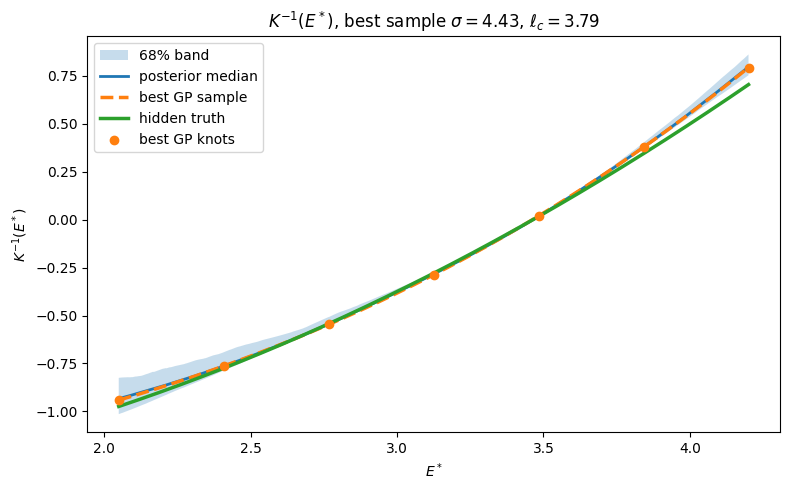

In [ ]:
E_plot = np.linspace(E_min, E_max, 500)

f_samples_plot = np.array([
    Kinv_gp_values(samples_f[i], samples_sigma[i], samples_lc[i], E_plot)
    for i in np.linspace(0, len(samples_f)-1, min(500, len(samples_f)), dtype=int)
])

f_low, f_med, f_high = np.percentile(f_samples_plot, [16, 50, 84], axis=0)

plt.figure(figsize=(8, 5))
plt.fill_between(E_plot, f_low, f_high, alpha=0.25, label="68% band")
plt.plot(E_plot, f_med, linewidth=2.0, label="posterior median")

best_plot = Kinv_gp_values(best_f, best_sigma, best_lc, E_plot)
plt.plot(E_plot, best_plot, "--", linewidth=2.5, label="best GP sample")
plt.plot(E_plot, Kinv_true(E_plot), linewidth=2.5, label="hidden truth")
plt.scatter(knots, best_f, zorder=5, label="best GP knots")

plt.xlabel(r"$E^*$")
plt.ylabel(r"$K^{-1}(E^*)$")
plt.title(rf"$K^{{-1}}(E^*)$, best sample $\sigma={best_sigma:.3g}$, $\ell_c={best_lc:.3g}$")
plt.legend()
plt.tight_layout()
plt.show()

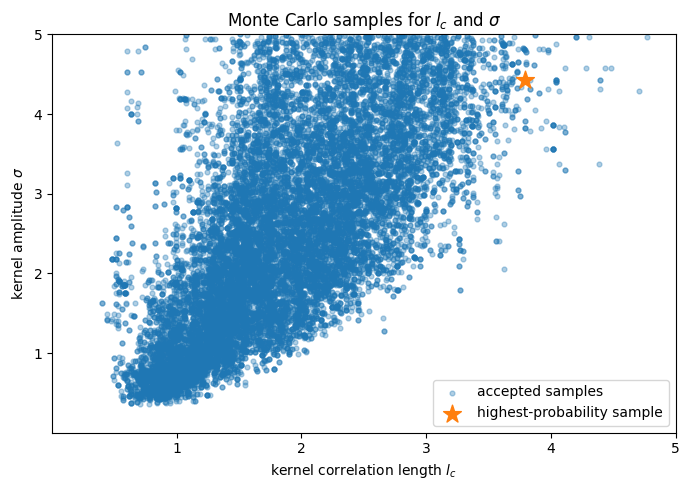

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(samples_lc, samples_sigma, s=12, alpha=0.35, label="accepted samples")
plt.scatter([best_lc], [best_sigma], marker="*", s=180, label="highest-probability sample")
plt.xlim(lc_min, lc_max)
plt.ylim(sigma_min, sigma_max)
plt.xlabel(r"kernel correlation length $l_c$")
plt.ylabel(r"kernel amplitude $\sigma$")
plt.title(r"Monte Carlo samples for $l_c$ and $\sigma$")
plt.legend()
plt.tight_layout()
plt.show()
#plt.figure(figsize=(8, 4))
#plt.plot(logpost_samples, label="log posterior")
#plt.plot(loglike_samples, label="log likelihood")
#plt.plot(logprior_samples, label="log prior")
#plt.xlabel("saved sample")
#plt.ylabel("log probability")
#plt.title("Posterior trace pieces")
#plt.legend()
#plt.tight_layout()
#plt.show()


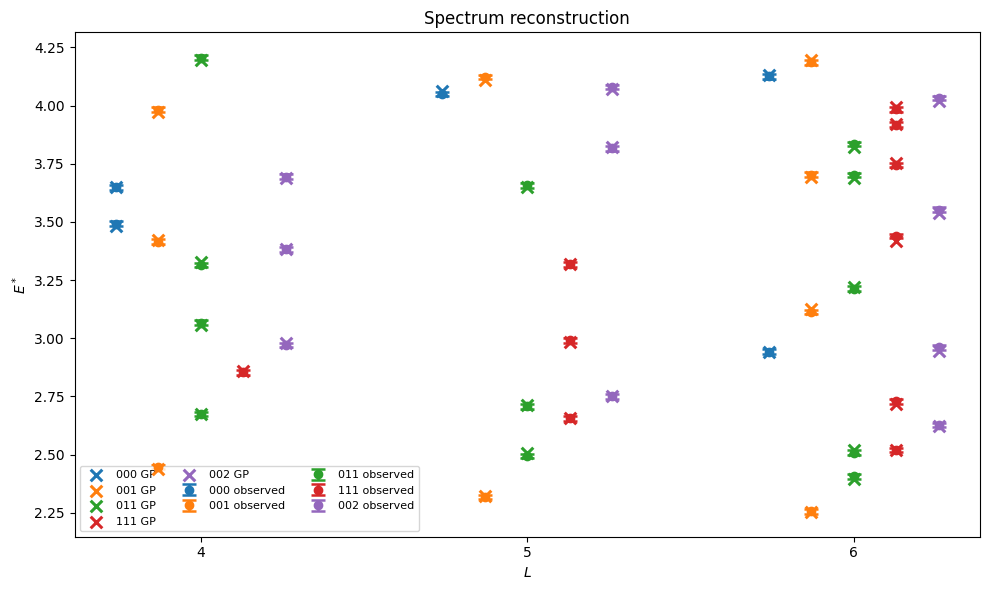

In [ ]:
_, _, _, interp_best = gp_matrices(best_sigma, best_lc)

predicted_rows = []
for L in Ls:
    for frame in frame_names:
        for level_index, E_pred in enumerate(predict_levels_from_gp(best_f, interp_best, L, frame)):
            predicted_rows.append({
                "L": float(L),
                "frame": frame,
                "level_index": level_index,
                "E_pred": float(E_pred),
            })

plot_spectrum(
    data,
    "Spectrum reconstruction",
    include_observed=True,
    include_true=False,
    predicted_rows=predicted_rows,
)

Current plotting bounds:
l_c   range = [0.001, 5.0]
sigma range = [0.001, 5.0]

Actual sample ranges:
l_c   min/max = 0.397695, 4.7701
sigma min/max = 0.361612, 4.99941

2D marginal posterior mode:
l_c   = 1.05079
sigma = 0.85083

Best sample coordinates:
l_c   = 3.79108
sigma = 4.42757


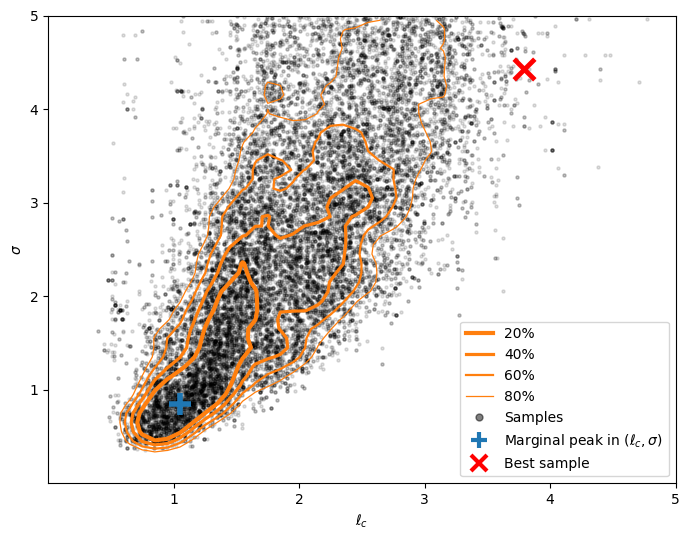

In [ ]:
from matplotlib.lines import Line2D

# Rebuild the 2D posterior density from the current MCMC samples.
# This is crucial: do not reuse stale H_plot / LC / lc_edges from an older run.
lc_samples = np.asarray(samples_lc, dtype=float)
sigma_samples = np.asarray(samples_sigma, dtype=float)

print("Current plotting bounds:")
print(f"l_c   range = [{lc_min}, {lc_max}]")
print(f"sigma range = [{sigma_min}, {sigma_max}]")
print()
print("Actual sample ranges:")
print(f"l_c   min/max = {np.min(lc_samples):.6g}, {np.max(lc_samples):.6g}")
print(f"sigma min/max = {np.min(sigma_samples):.6g}, {np.max(sigma_samples):.6g}")

if len(lc_samples) < 5:
    raise ValueError("Need at least a few saved posterior samples before making the contour plot.")

n_bins_lc = 50
n_bins_sigma = 50

H, lc_edges, sigma_edges = np.histogram2d(
    lc_samples,
    sigma_samples,
    bins=(n_bins_lc, n_bins_sigma),
    range=((lc_min, lc_max), (sigma_min, sigma_max)),
    density=True,
)

try:
    from scipy.ndimage import gaussian_filter
    H_plot = gaussian_filter(H, sigma=1.0)
except Exception:
    H_plot = H

lc_centers = 0.5*(lc_edges[:-1] + lc_edges[1:])
sigma_centers = 0.5*(sigma_edges[:-1] + sigma_edges[1:])
LC, SIGMA = np.meshgrid(lc_centers, sigma_centers, indexing="ij")


def hpd_density_level(H_density, x_edges, y_edges, mass):
    dx = np.diff(x_edges)[:, None]
    dy = np.diff(y_edges)[None, :]
    cell_mass = H_density*dx*dy

    order = np.argsort(H_density.ravel())[::-1]
    sorted_density = H_density.ravel()[order]
    sorted_mass = cell_mass.ravel()[order]

    cumulative_mass = np.cumsum(sorted_mass)
    cumulative_mass /= cumulative_mass[-1]

    idx = np.searchsorted(cumulative_mass, mass)
    idx = min(idx, len(sorted_density) - 1)

    return sorted_density[idx]


plt.figure(figsize=(7, 5.5))
ax = plt.gca()
ax.set_facecolor("white")

# HPD contours at 20%, 40%, 60%, 80%.
# Here 20% is the innermost/highest-density contour.
masses = [0.20, 0.40, 0.60, 0.80]
levels = [hpd_density_level(H_plot, lc_edges, sigma_edges, m) for m in masses]

# Matplotlib needs increasing density levels.
level_mass_pairs = sorted(zip(levels, masses), key=lambda x: x[0])
contour_levels = [x[0] for x in level_mass_pairs]
contour_masses = [x[1] for x in level_mass_pairs]

# Reverse thickness convention:
# thickest = 20%, thinnest = 80%.
linewidth_map = {
    0.20: 3.0,
    0.40: 2.3,
    0.60: 1.6,
    0.80: 0.9,
}
linewidths = [linewidth_map[m] for m in contour_masses]

plt.contour(
    LC,
    SIGMA,
    H_plot,
    levels=contour_levels,
    colors="C1",
    linewidths=linewidths,
)

# Posterior sample cloud
plt.scatter(
    lc_samples,
    sigma_samples,
    s=5,
    alpha=0.12,
    color="black",
)

# 2D marginal mode from the same density used for the contours
imax, jmax = np.unravel_index(np.argmax(H_plot), H_plot.shape)
mode_lc_2d = lc_centers[imax]
mode_sigma_2d = sigma_centers[jmax]

print()
print("2D marginal posterior mode:")
print(f"l_c   = {mode_lc_2d:.6g}")
print(f"sigma = {mode_sigma_2d:.6g}")

print()
print("Best sample coordinates:")
print(f"l_c   = {best_lc:.6g}")
print(f"sigma = {best_sigma:.6g}")

# Blue plus: peak of the marginalized (l_c, sigma) density
plt.scatter(
    [mode_lc_2d],
    [mode_sigma_2d],
    marker="+",
    s=260,
    color="C0",
    linewidths=4,
    zorder=12,
)

# Red cross: best sample
plt.scatter(
    [best_lc],
    [best_sigma],
    marker="x",
    s=220,
    color="red",
    linewidths=3.5,
    zorder=13,
)

plt.xlim(lc_min, lc_max)
plt.ylim(sigma_min, sigma_max)
plt.xlabel(r"$\ell_c$")
plt.ylabel(r"$\sigma$")

legend_handles = [
    Line2D([0], [0], color="C1", lw=3.0, label="20%"),
    Line2D([0], [0], color="C1", lw=2.3, label="40%"),
    Line2D([0], [0], color="C1", lw=1.6, label="60%"),
    Line2D([0], [0], color="C1", lw=0.9, label="80%"),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color="black",
        markersize=5,
        alpha=0.5,
        label="Samples",
    ),
    Line2D(
        [0], [0],
        marker="+",
        linestyle="None",
        color="C0",
        markersize=12,
        markeredgewidth=3,
        label=r"Marginal peak in $(\ell_c,\sigma)$",
    ),
    Line2D(
        [0], [0],
        marker="x",
        linestyle="None",
        color="red",
        markersize=11,
        markeredgewidth=3,
        label="Best sample",
    ),
]

plt.legend(handles=legend_handles, loc="best")
plt.tight_layout()
plt.show()

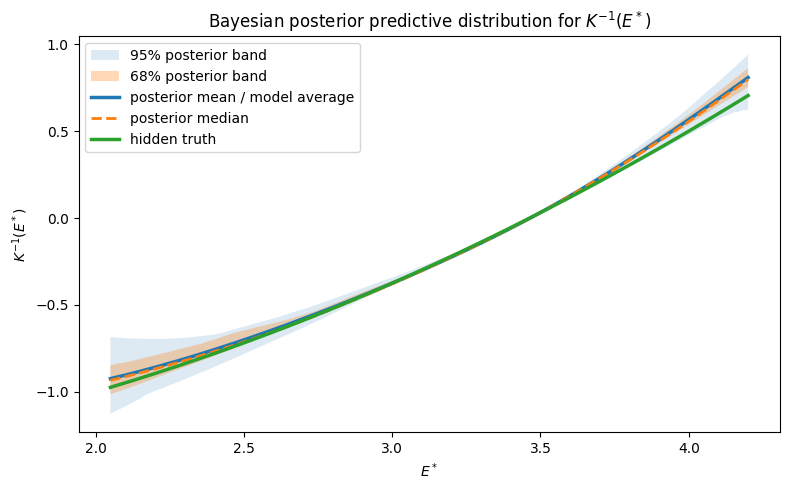

In [ ]:
# ============================================================
# Final Bayesian model-averaged posterior predictive plot
# ============================================================

# This cell uses the saved beta=1 samples:
#   samples_f, samples_sigma, samples_lc
#
# Each saved MCMC sample is one draw from
#
#   p(f_knots, sigma, l_c | finite-volume spectrum).
#
# Therefore the posterior predictive distribution for K^{-1}(E*)
# is approximated by evaluating K^{-1}(E*) for every saved sample.

E_plot = np.linspace(E_min, E_max, 500)

if len(samples_f) == 0:
    raise ValueError("No posterior samples found. Run the MCMC cell first.")

# Evaluate K^{-1}(E*) for every posterior sample.
# Shape: (n_samples, len(E_plot))
Kinv_posterior_samples = np.array([
    Kinv_gp_values(f, sigma, l_c, E_plot)
    for f, sigma, l_c in zip(samples_f, samples_sigma, samples_lc)
])

# Bayesian model-averaged central curve.
# This is the posterior mean:
#
#   E[K^{-1}(E*) | data]
#
Kinv_mean = np.mean(Kinv_posterior_samples, axis=0)

# Pointwise posterior credible bands.
Kinv_low_68, Kinv_med, Kinv_high_68 = np.percentile(
    Kinv_posterior_samples,
    [16, 50, 84],
    axis=0,
)

Kinv_low_95, Kinv_high_95 = np.percentile(
    Kinv_posterior_samples,
    [2.5, 97.5],
    axis=0,
)

plt.figure(figsize=(8, 5))

plt.fill_between(
    E_plot,
    Kinv_low_95,
    Kinv_high_95,
    alpha=0.15,
    label="95% posterior band",
)

plt.fill_between(
    E_plot,
    Kinv_low_68,
    Kinv_high_68,
    alpha=0.30,
    label="68% posterior band",
)

plt.plot(
    E_plot,
    Kinv_mean,
    linewidth=2.5,
    label=r"posterior mean / model average",
)

plt.plot(
    E_plot,
    Kinv_med,
    "--",
    linewidth=2.0,
    label=r"posterior median",
)

# Only include this because this is mock data and we know the hidden answer.
plt.plot(
    E_plot,
    Kinv_true(E_plot),
    linewidth=2.5,
    label="hidden truth",
)

plt.xlabel(r"$E^*$")
plt.ylabel(r"$K^{-1}(E^*)$")
plt.title(r"Bayesian posterior predictive distribution for $K^{-1}(E^*)$")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Print Bayesian summary of the hyperparameters
# ============================================================

sigma_mean = np.mean(samples_sigma)
sigma_low, sigma_med, sigma_high = np.percentile(samples_sigma, [16, 50, 84])

lc_mean = np.mean(samples_lc)
lc_low, lc_med, lc_high = np.percentile(samples_lc, [16, 50, 84])

#print("Bayesian posterior summary")
#print("--------------------------")
#print(f"number of posterior samples = {len(samples_f)}")
#print()
##print(f"sigma posterior mean  = {sigma_mean:.6g}")
#print(f"sigma posterior median = {sigma_med:.6g}")
#print(f"sigma 68% interval     = [{sigma_low:.6g}, {sigma_high:.6g}]")
#print()
#print(f"l_c posterior mean     = {lc_mean:.6g}")
#print(f"l_c posterior median   = {lc_med:.6g}")
#print(f"l_c 68% interval       = [{lc_low:.6g}, {lc_high:.6g}]")




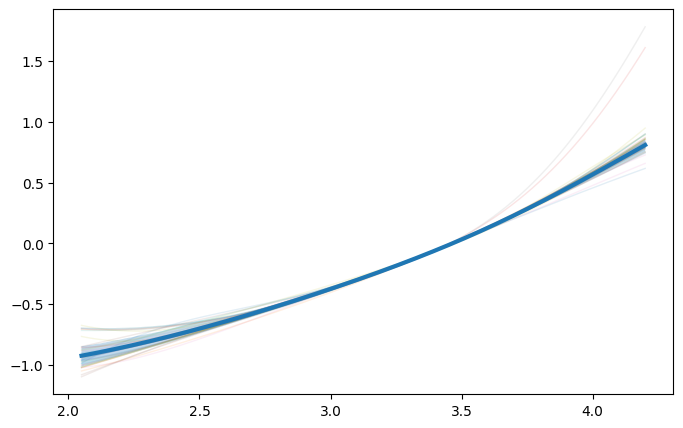

In [ ]:
# ============================================================
# Optional: show a few posterior draws, not as the answer,
# but as a visual reminder that the band comes from many curves.
# ============================================================

n_draws_to_show = min(40, len(samples_f))
draw_ids = rng.choice(len(samples_f), size=n_draws_to_show, replace=False)

plt.figure(figsize=(8, 5))

for i in draw_ids:
    plt.plot(
        E_plot,
        Kinv_posterior_samples[i],
        alpha=0.12,
        linewidth=1.0,
    )

plt.plot(
    E_plot,
    Kinv_mean,
    linewidth=3.0,
    label=r"posterior mean / model average",
)

plt.fill_between(
    E_plot,
    Kinv_low_68,
    Kinv_high_68,
    alpha=0.25,
    label="68% posterior band",
)

#plt.plot(
#    E_plot,
#    Kinv_true(E_plot),
#    linewidth=2.5,
#    label="hidden truth",
#)

#plt.xlabel(r"$E^*$")
#plt.ylabel(r"$K^{-1}(E^*)$")
#plt.title(r"Posterior samples contributing to the Bayesian model average")
#plt.legend()
#plt.tight_layout()
plt.show()

In [ ]:
print(rng)

Generator(PCG64)


In [ ]:
rng = np.random.default_rng(1234)

print(rng.bit_generator.state)

{'bit_generator': 'PCG64', 'state': {'state': 29299324949094424543410418505067287561, 'inc': 107381791681050441119675421997145146149}, 'has_uint32': 0, 'uinteger': 0}


In [ ]:
saved_state = rng.bit_generator.state

In [ ]:
rng2 = np.random.default_rng()
rng2.bit_generator.state = saved_state

In [ ]:
import json

rng_state = rng.bit_generator.state

with open("rng_state.json", "w") as f:
    json.dump(rng_state, f)

Sample closest to 2D marginal posterior mode
index = 2908
sigma = 0.85133
l_c   = 1.04867
log posterior  = 149.371
log likelihood = 145.103
log prior      = 4.268

2D marginal peak coordinates
sigma = 0.85083
l_c   = 1.05079


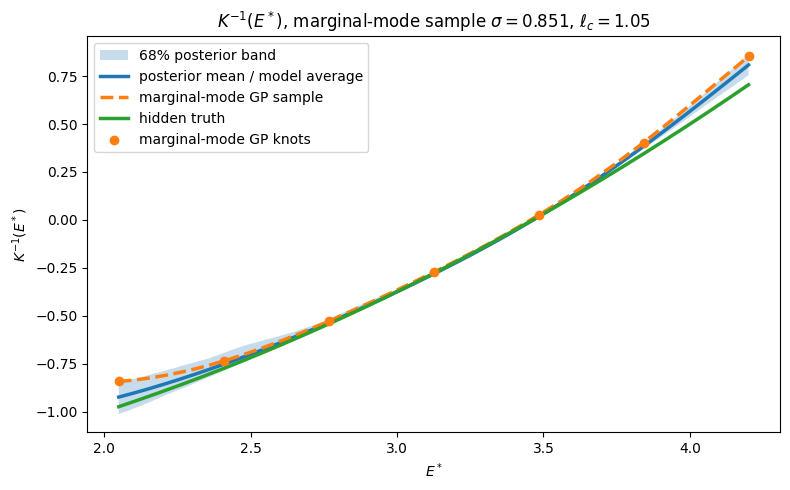

In [ ]:
# ============================================================
# Plot the sample closest to the 2D marginal posterior mode
# with the same bells and whistles as the best sample
# ============================================================

if len(samples_f) == 0:
    raise ValueError("No posterior samples found. Run the MCMC cell first.")

# The contour cell defines these:
#   mode_lc_2d
#   mode_sigma_2d
#
# Now choose the actual saved MCMC sample closest to that 2D marginal peak.
# Use fractional distance so l_c and sigma are weighted comparably.
dist_to_mode = (
    ((samples_lc - mode_lc_2d)/(lc_max - lc_min))**2
    +
    ((samples_sigma - mode_sigma_2d)/(sigma_max - sigma_min))**2
)

mode_index = int(np.argmin(dist_to_mode))

mode_f = samples_f[mode_index]
mode_sigma = samples_sigma[mode_index]
mode_lc = samples_lc[mode_index]
mode_logpost = logpost_samples[mode_index]
mode_loglike = loglike_samples[mode_index]
mode_logprior = logprior_samples[mode_index]

print("Sample closest to 2D marginal posterior mode")
print("index =", mode_index)
print(f"sigma = {mode_sigma:.6g}")
print(f"l_c   = {mode_lc:.6g}")
print(f"log posterior  = {mode_logpost:.3f}")
print(f"log likelihood = {mode_loglike:.3f}")
print(f"log prior      = {mode_logprior:.3f}")
print()
print("2D marginal peak coordinates")
print(f"sigma = {mode_sigma_2d:.6g}")
print(f"l_c   = {mode_lc_2d:.6g}")


# ============================================================
# K^{-1}(E*) plot for marginal-mode sample
# ============================================================

E_plot = np.linspace(E_min, E_max, 500)

Kinv_mode = Kinv_gp_values(mode_f, mode_sigma, mode_lc, E_plot)

plt.figure(figsize=(8, 5))

# Use the existing posterior band if it has already been computed.
try:
    plt.fill_between(
        E_plot,
        Kinv_low_68,
        Kinv_high_68,
        alpha=0.25,
        label="68% posterior band",
    )
    plt.plot(
        E_plot,
        Kinv_mean,
        linewidth=2.5,
        label="posterior mean / model average",
    )
except NameError:
    pass

plt.plot(
    E_plot,
    Kinv_mode,
    "--",
    linewidth=2.5,
    label="marginal-mode GP sample",
)

plt.plot(
    E_plot,
    Kinv_true(E_plot),
    linewidth=2.5,
    label="hidden truth",
)

plt.scatter(
    knots,
    mode_f,
    zorder=5,
    label="marginal-mode GP knots",
)

plt.xlabel(r"$E^*$")
plt.ylabel(r"$K^{-1}(E^*)$")
plt.title(
    rf"$K^{{-1}}(E^*)$, marginal-mode sample "
    rf"$\sigma={mode_sigma:.3g}$, $\ell_c={mode_lc:.3g}$"
)
plt.legend()
plt.tight_layout()
plt.show()

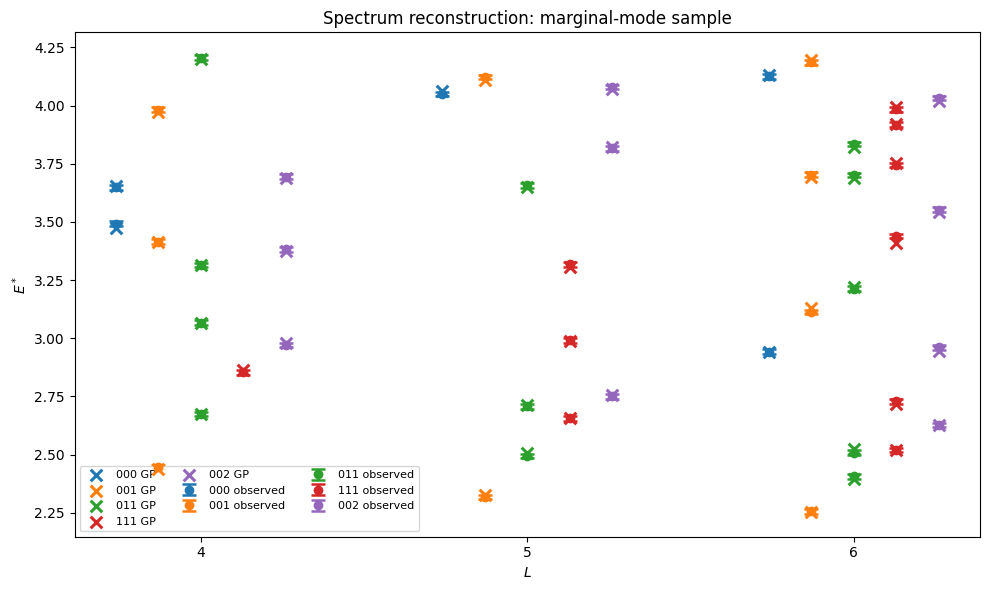

In [ ]:
# ============================================================
# Finite-volume spectrum from marginal-mode sample
# ============================================================

_, _, _, interp_mode = gp_matrices(mode_sigma, mode_lc)

predicted_rows_mode = []

for L in Ls:
    for frame in frame_names:
        for level_index, E_pred in enumerate(
            predict_levels_from_gp(mode_f, interp_mode, L, frame)
        ):
            predicted_rows_mode.append({
                "L": float(L),
                "frame": frame,
                "level_index": level_index,
                "E_pred": float(E_pred),
            })

plot_spectrum(
    data,
    "Spectrum reconstruction: marginal-mode sample",
    include_observed=True,
    include_true=False,
    predicted_rows=predicted_rows_mode,
)

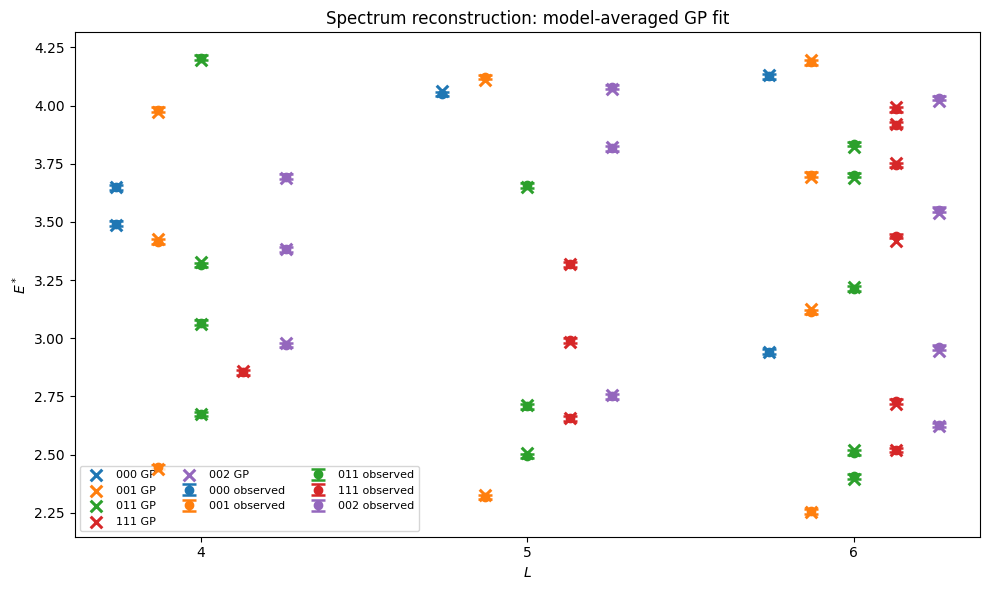

In [ ]:
# ============================================================
# Spectrum reconstruction from the model-averaged GP fit
# ============================================================

if len(samples_f) == 0:
    raise ValueError("No posterior samples found. Run the MCMC cell first.")

# Evaluate every posterior sample on the same E_grid used for root finding.
# Shape: (n_samples, len(E_grid))
Kinv_grid_samples = np.array([
    Kinv_gp_values(f, sigma, l_c, E_grid)
    for f, sigma, l_c in zip(samples_f, samples_sigma, samples_lc)
])

# Bayesian model-averaged K^{-1}(E*) on the root-finding grid.
Kinv_grid_model_avg = np.mean(Kinv_grid_samples, axis=0)

predicted_rows_model_avg = []

for L in Ls:
    for frame in frame_names:

        # Quantization condition using the model-averaged K^{-1}
        QC_model_avg = Kinv_grid_model_avg + F_grids[(float(L), frame)]

        levels_model_avg = roots_from_grid(QC_model_avg, L, frame)

        for level_index, E_pred in enumerate(levels_model_avg):
            predicted_rows_model_avg.append({
                "L": float(L),
                "frame": frame,
                "level_index": level_index,
                "E_pred": float(E_pred),
            })

plot_spectrum(
    data,
    "Spectrum reconstruction: model-averaged GP fit",
    include_observed=True,
    include_true=False,
    predicted_rows=predicted_rows_model_avg,
)